# (Optional) Colab Setup
If you aren't using Colab, you can delete the following code cell. This is just to help students with mounting to Google Drive to access the other .py files and downloading the data, which is a little trickier on Colab than on your local machine using Jupyter.

In [2]:
# you will be prompted with a window asking to grant permissions
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# fill in the path in your Google Drive in the string below. Note: do not escape slashes or spaces
import os
datadir = "/content/assignment3"
if not os.path.exists(datadir):
  !ln -s "/content/drive/My Drive/assignment3/" $datadir # TODO: Fill your assignment3 path
os.chdir(datadir)
!pwd

/content/drive/My Drive/assignment3


# Data Setup

The first thing to do is implement a dataset class to load rotated CIFAR10 images with matching labels. Since there is already a CIFAR10 dataset class implemented in `torchvision`, we will extend this class and modify the `__get_item__` method appropriately to load rotated images.

Each rotation label should be an integer in the set {0, 1, 2, 3} which correspond to rotations of 0, 90, 180, or 270 degrees respectively.

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random


def rotate_img(img, rot):
    if rot == 0: # 0 degrees rotation
        return img
    if rot == 1: # 90 degrees rotation
        return transforms.functional.rotate(img, 90)
    elif rot == 2: # 180 degrees rotation
        return transforms.functional.rotate(img, 180)
    elif rot == 3: # 270 degrees rotation
        return transforms.functional.rotate(img, 270)
    else:
        raise ValueError('rotation should be 0, 90, 180, or 270 degrees')


class CIFAR10Rotation(torchvision.datasets.CIFAR10):

    def __init__(self, root, train, download, transform) -> None:
        super().__init__(root=root, train=train, download=download, transform=transform)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index: int):
        image, cls_label = super().__getitem__(index)

        # randomly select image rotation
        rotation_label = random.choice([0, 1, 2, 3])
        image_rotated = rotate_img(image, rotation_label)

        rotation_label = torch.tensor(rotation_label).long()
        return image, image_rotated, rotation_label, torch.tensor(cls_label).long()

In [ ]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

batch_size = 128

trainset = CIFAR10Rotation(root='./data', train=True,
                                        download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = CIFAR10Rotation(root='./data', train=False,
                                       download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

Show some example images and rotated images with labels:

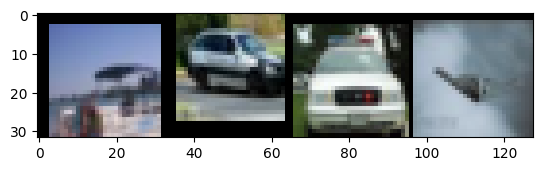

Class labels:  ship  car   car   plane


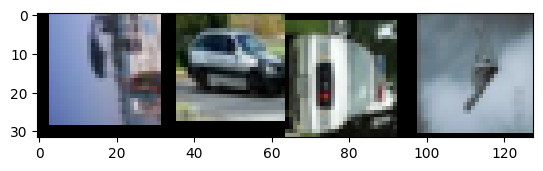

Rotation labels:  90    0     270   90   


In [ ]:
import matplotlib.pyplot as plt

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

rot_classes = ('0', '90', '180', '270')


def imshow(img):
    # unnormalize
    img = transforms.Normalize((0, 0, 0), (1/0.2023, 1/0.1994, 1/0.2010))(img)
    img = transforms.Normalize((-0.4914, -0.4822, -0.4465), (1, 1, 1))(img)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


dataiter = iter(trainloader)
images, rot_images, rot_labels, labels = next(dataiter)

# print images and rotated images
img_grid = imshow(torchvision.utils.make_grid(images[:4], padding=0))
print('Class labels: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))
img_grid = imshow(torchvision.utils.make_grid(rot_images[:4], padding=0))
print('Rotation labels: ', ' '.join(f'{rot_classes[rot_labels[j]]:5s}' for j in range(4)))

# Evaluation code

In [ ]:
import time

def run_test(net, testloader, criterion, task):
    correct = 0
    total = 0
    avg_test_loss = 0.0
    # since we're not training, we don't need to calculate the gradients for our outputs
    with torch.no_grad():
        for images, images_rotated, labels, cls_labels in testloader:
            if task == 'rotation':
              images, labels = images_rotated.to(device), labels.to(device)
            elif task == 'classification':
              images, labels = images.to(device), cls_labels.to(device)
            # TODO: Calculate outputs by running images through the network
            # The class with the highest energy is what we choose as prediction
            #
            #
            #
            outputs = net(images)
            _, predicted = torch.max(outputs.data, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # loss
            avg_test_loss += criterion(outputs, labels)  / len(testloader)
    print('TESTING:')
    print(f'Accuracy of the network on the 10000 test images: {100 * correct / total:.2f} %')
    print(f'Average loss on the 10000 test images: {avg_test_loss:.3f}')
    return correct / total

In [ ]:
def adjust_learning_rate(optimizer, epoch, init_lr, decay_epochs=30):
    """Sets the learning rate to the initial LR decayed by 10 every 30 epochs"""
    lr = init_lr * (0.1 ** (epoch // decay_epochs))
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

## 1. Train a ResNet18 on the rotation task

In this section, we will train a ResNet18 model on the rotation task. The input is a rotated image and the model predicts the rotation label. See the Data Setup section for details.

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

net = resnet18(num_classes=4)
net = net.to(device)

In [ ]:
import torch.optim as optim

# TODO: Define criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters())

In [ ]:
# Both the self-supervised rotation task and supervised CIFAR10 classification are
# trained with the CrossEntropyLoss, so we can use the training loop code.

def train(net, criterion, optimizer, num_epochs, decay_epochs, init_lr, task, baseline = 0.9):

    for epoch in range(num_epochs):  # loop over the dataset multiple times

        running_loss = 0.0
        running_correct = 0.0
        running_total = 0.0
        start_time = time.time()

        net.train()

        for i, (imgs, imgs_rotated, rotation_label, cls_label) in enumerate(trainloader, 0):
            adjust_learning_rate(optimizer, epoch, init_lr, decay_epochs)

            # TODO: Set the data to the correct device; Different task will use different inputs and labels
            if task == 'rotation':
              imgs, labels = imgs_rotated.to(device), rotation_label.to(device)
            elif task == 'classification':
              imgs, labels = imgs.to(device), cls_label.to(device)

            # TODO: Zero the parameter gradients
            net.zero_grad()

            # TODO: forward + backward + optimize
            out = net(imgs)
            loss = criterion(out, labels)
            loss.backward()

            optimizer.step()

            # TODO: Get predicted result
            #
            #
            _, predicted = torch.max(out.data, dim=1)

            predicted.to(device)
            labels.to(device)
            # print statistics
            print_freq = 100
            running_loss += loss.item()

            # calc acc
            running_total += labels.size(0)
            running_correct += (predicted == labels).sum().item()

            if i % print_freq == (print_freq - 1):    # print every 2000 mini-batches
                print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / print_freq:.3f} acc: {100*running_correct / running_total:.2f} time: {time.time() - start_time:.2f}')
                running_loss, running_correct, running_total = 0.0, 0.0, 0.0
                start_time = time.time()

        # TODO: Run the run_test() function after each epoch; Set the model to the evaluation mode.
        #
        #
        net.eval()

        acc = run_test(net, testloader, criterion, task)
        if acc >= baseline: # early stopping if baseline is achieved
          break

    print('Finished Training')

In [ ]:
train(net, criterion, optimizer, num_epochs=45, decay_epochs=15, init_lr=0.01, task='rotation', baseline=0.78)

# TODO: Save the model
#
torch.save(net.state_dict(), '/content/drive/My Drive/assignment3/rotation_model_new.pt')

[1,   100] loss: 1.469 acc: 35.40 time: 8.32
[1,   200] loss: 1.257 acc: 46.09 time: 8.26
[1,   300] loss: 1.182 acc: 48.63 time: 8.96
TESTING:
Accuracy of the network on the 10000 test images: 52.68 %
Average loss on the 10000 test images: 1.093
[2,   100] loss: 1.096 acc: 53.20 time: 8.06
[2,   200] loss: 1.074 acc: 53.40 time: 8.96
[2,   300] loss: 1.061 acc: 54.70 time: 7.26
TESTING:
Accuracy of the network on the 10000 test images: 55.89 %
Average loss on the 10000 test images: 1.043
[3,   100] loss: 1.031 acc: 55.79 time: 8.94
[3,   200] loss: 1.020 acc: 56.72 time: 7.39
[3,   300] loss: 1.013 acc: 57.24 time: 8.51
TESTING:
Accuracy of the network on the 10000 test images: 57.95 %
Average loss on the 10000 test images: 0.994
[4,   100] loss: 0.983 acc: 58.29 time: 7.57
[4,   200] loss: 0.955 acc: 59.89 time: 8.60
[4,   300] loss: 0.970 acc: 59.40 time: 7.40
TESTING:
Accuracy of the network on the 10000 test images: 60.24 %
Average loss on the 10000 test images: 0.934
[5,   100] l

## 2.1 Fine-tuning on the pre-trained model

In this section, we will load the pre-trained ResNet18 model and fine-tune on the classification task. We will freeze all previous layers except for the 'layer4' block and 'fc' layer.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

# TODO: Load the pre-trained ResNet18 model
#
#
net = resnet18(num_classes=4)
net.load_state_dict(torch.load('/content/drive/My Drive/assignment3/rotation_model_new.pt', map_location=device))
net = net.to(device)


In [ ]:
# TODO: Freeze all previous layers; only keep the 'layer4' block and 'fc' layer trainable
#
#
#
#
for param in net.parameters():
    param.requires_grad = False



for param in net.layer4.parameters():
  param.requires_grad = True

net.fc = nn.Linear(net.fc.in_features, 10).to(device) # Replace with a new fc layer with 10 output features
net.fc.weight.requires_grad = True
net.fc.bias.requires_grad = True

In [ ]:
# Print all the trainable parameters
params_to_update = net.parameters()
print("Params to learn:")
params_to_update = []
for name,param in net.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)
        print("\t",name)

Params to learn:
	 layer4.0.conv1.weight
	 layer4.0.bn1.weight
	 layer4.0.bn1.bias
	 layer4.0.conv2.weight
	 layer4.0.bn2.weight
	 layer4.0.bn2.bias
	 layer4.0.downsample.0.weight
	 layer4.0.downsample.1.weight
	 layer4.0.downsample.1.bias
	 layer4.1.conv1.weight
	 layer4.1.bn1.weight
	 layer4.1.bn1.bias
	 layer4.1.conv2.weight
	 layer4.1.bn2.weight
	 layer4.1.bn2.bias
	 fc.weight
	 fc.bias


In [ ]:
# TODO: Define criterion and optimizer
# Note that your optimizer only needs to update the parameters that are trainable.
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(params_to_update)

In [ ]:
train(net, criterion, optimizer, num_epochs=20, decay_epochs=10, init_lr=0.01, task='classification')
torch.save(net.state_dict(), '/content/drive/My Drive/assignment3/classmodel_pre-trained_adam.pt')


[1,   100] loss: 1.771 acc: 34.25 time: 8.27
[1,   200] loss: 1.481 acc: 45.86 time: 7.74
[1,   300] loss: 1.422 acc: 47.91 time: 7.42
TESTING:
Accuracy of the network on the 10000 test images: 48.89 %
Average loss on the 10000 test images: 1.424
[2,   100] loss: 1.367 acc: 49.70 time: 7.38
[2,   200] loss: 1.356 acc: 50.88 time: 7.85
[2,   300] loss: 1.337 acc: 50.90 time: 7.66
TESTING:
Accuracy of the network on the 10000 test images: 53.41 %
Average loss on the 10000 test images: 1.284
[3,   100] loss: 1.323 acc: 51.70 time: 8.57
[3,   200] loss: 1.323 acc: 52.31 time: 7.52
[3,   300] loss: 1.302 acc: 52.48 time: 7.99
TESTING:
Accuracy of the network on the 10000 test images: 54.85 %
Average loss on the 10000 test images: 1.250
[4,   100] loss: 1.282 acc: 53.56 time: 7.18
[4,   200] loss: 1.276 acc: 53.52 time: 8.28
[4,   300] loss: 1.276 acc: 53.91 time: 7.91
TESTING:
Accuracy of the network on the 10000 test images: 56.09 %
Average loss on the 10000 test images: 1.218
[5,   100] l

## 2.2 Fine-tuning on the randomly initialized model
In this section, we will randomly initialize a ResNet18 model and fine-tune on the classification task. We will freeze all previous layers except for the 'layer4' block and 'fc' layer.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

# TODO: Randomly initialize a ResNet18 model
net = resnet18(num_classes=10)
net = net.to(device)

In [ ]:
# TODO: Freeze all previous layers; only keep the 'layer4' block and 'fc' layer trainable
# To do this, you should set requires_grad=False for the frozen layers.
#
#
#
for param in net.parameters():
    param.requires_grad = False



for param in net.layer4.parameters():
  param.requires_grad = True

net.fc.weight.requires_grad = True
net.fc.bias.requires_grad = True

In [ ]:
# Print all the trainable parameters
params_to_update = net.parameters()
print("Params to learn:")
params_to_update = []
for name,param in net.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)
        print("\t",name)

Params to learn:
	 layer4.0.conv1.weight
	 layer4.0.bn1.weight
	 layer4.0.bn1.bias
	 layer4.0.conv2.weight
	 layer4.0.bn2.weight
	 layer4.0.bn2.bias
	 layer4.0.downsample.0.weight
	 layer4.0.downsample.1.weight
	 layer4.0.downsample.1.bias
	 layer4.1.conv1.weight
	 layer4.1.bn1.weight
	 layer4.1.bn1.bias
	 layer4.1.conv2.weight
	 layer4.1.bn2.weight
	 layer4.1.bn2.bias
	 fc.weight
	 fc.bias


In [ ]:
# TODO: Define criterion and optimizer
# Note that your optimizer only needs to update the parameters that are trainable.
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(params_to_update)

In [ ]:
train(net, criterion, optimizer, num_epochs=20, decay_epochs=10, init_lr=0.01, task='classification')
torch.save(net.state_dict(), '/content/drive/My Drive/assignment3/classmodel_random_adam.pt')

[1,   100] loss: 2.257 acc: 25.20 time: 9.28
[1,   200] loss: 1.968 acc: 29.84 time: 8.35
[1,   300] loss: 1.883 acc: 31.62 time: 7.56
TESTING:
Accuracy of the network on the 10000 test images: 35.99 %
Average loss on the 10000 test images: 1.755
[2,   100] loss: 1.828 acc: 33.78 time: 8.84
[2,   200] loss: 1.796 acc: 34.74 time: 7.47
[2,   300] loss: 1.785 acc: 35.43 time: 8.98
TESTING:
Accuracy of the network on the 10000 test images: 36.65 %
Average loss on the 10000 test images: 1.734
[3,   100] loss: 1.752 acc: 36.84 time: 7.39
[3,   200] loss: 1.757 acc: 36.62 time: 8.83
[3,   300] loss: 1.726 acc: 37.80 time: 7.12
TESTING:
Accuracy of the network on the 10000 test images: 39.75 %
Average loss on the 10000 test images: 1.669
[4,   100] loss: 1.735 acc: 37.32 time: 8.78
[4,   200] loss: 1.714 acc: 38.17 time: 7.23
[4,   300] loss: 1.726 acc: 37.52 time: 8.65
TESTING:
Accuracy of the network on the 10000 test images: 39.97 %
Average loss on the 10000 test images: 1.659
[5,   100] l

## 3.1 Supervised training on the pre-trained model
In this section, we will load the pre-trained ResNet18 model and re-train the whole model on the classification task.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

# TODO: Load the pre-trained ResNet18 model
net = resnet18(num_classes=4)
net.load_state_dict(torch.load('/content/drive/My Drive/assignment3/rotation_model_new.pt', map_location=device))
net = net.to(device)
net.fc = nn.Linear(net.fc.in_features, 10).to(device)

In [ ]:
# TODO: Define criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters())

In [ ]:
train(net, criterion, optimizer, num_epochs=20, decay_epochs=10, init_lr=0.01, task='classification', baseline = 0.8)
torch.save(net.state_dict(), '/content/drive/My Drive/assignment3/classmodel_pretrain_full_adam.pt')

[1,   100] loss: 1.465 acc: 44.78 time: 8.81
[1,   200] loss: 1.175 acc: 57.71 time: 8.53
[1,   300] loss: 1.086 acc: 61.46 time: 9.19
TESTING:
Accuracy of the network on the 10000 test images: 64.24 %
Average loss on the 10000 test images: 1.023
[2,   100] loss: 0.951 acc: 66.39 time: 8.82
[2,   200] loss: 0.911 acc: 67.58 time: 10.39
[2,   300] loss: 0.915 acc: 68.17 time: 9.09
TESTING:
Accuracy of the network on the 10000 test images: 71.22 %
Average loss on the 10000 test images: 0.835
[3,   100] loss: 0.836 acc: 70.95 time: 8.64
[3,   200] loss: 0.821 acc: 71.73 time: 9.69
[3,   300] loss: 0.794 acc: 72.71 time: 8.66
TESTING:
Accuracy of the network on the 10000 test images: 70.53 %
Average loss on the 10000 test images: 0.852
[4,   100] loss: 0.749 acc: 74.14 time: 8.20
[4,   200] loss: 0.738 acc: 74.16 time: 9.95
[4,   300] loss: 0.743 acc: 74.37 time: 9.45
TESTING:
Accuracy of the network on the 10000 test images: 76.21 %
Average loss on the 10000 test images: 0.702
[5,   100] 

## 3.2 Supervised training on the randomly initialized model
In this section, we will randomly initialize a ResNet18 model and re-train the whole model on the classification task.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

# TODO: Randomly initialize a ResNet18 model
net = resnet18(num_classes=10)
net = net.to(device)

In [ ]:
# TODO: Define criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters())

In [ ]:
train(net, criterion, optimizer, num_epochs=20, decay_epochs=10, init_lr=0.01, task='classification', baseline=0.8)
torch.save(net.state_dict(), '/content/drive/My Drive/assignment3/classmodel_random_full_adam.pt')

[1,   100] loss: 2.289 acc: 21.58 time: 9.16
[1,   200] loss: 1.904 acc: 31.00 time: 9.12
[1,   300] loss: 1.819 acc: 33.36 time: 7.46
TESTING:
Accuracy of the network on the 10000 test images: 40.39 %
Average loss on the 10000 test images: 1.584
[2,   100] loss: 1.604 acc: 40.43 time: 10.24
[2,   200] loss: 1.531 acc: 44.05 time: 8.31
[2,   300] loss: 1.476 acc: 46.09 time: 8.93
TESTING:
Accuracy of the network on the 10000 test images: 51.80 %
Average loss on the 10000 test images: 1.375
[3,   100] loss: 1.352 acc: 50.69 time: 9.73
[3,   200] loss: 1.298 acc: 53.52 time: 7.85
[3,   300] loss: 1.248 acc: 55.17 time: 9.40
TESTING:
Accuracy of the network on the 10000 test images: 54.87 %
Average loss on the 10000 test images: 1.272
[4,   100] loss: 1.169 acc: 57.91 time: 8.79
[4,   200] loss: 1.128 acc: 59.60 time: 8.59
[4,   300] loss: 1.081 acc: 61.54 time: 9.32
TESTING:
Accuracy of the network on the 10000 test images: 65.51 %
Average loss on the 10000 test images: 1.007
[5,   100] 

# 4.A Improving Rotation

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import densenet121

net = densenet121(num_classes=4)
net = net.to(device)

In [ ]:
import torch.optim as optim

# TODO: Define criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters())

In [ ]:
train(net, criterion, optimizer, num_epochs=45, decay_epochs=15, init_lr=0.01, task='rotation')
torch.save(net.state_dict(), '/content/drive/My Drive/assignment3/rotation_model_densenet.pt')

[1,   100] loss: 1.150 acc: 49.48 time: 14.77
[1,   200] loss: 1.143 acc: 49.54 time: 12.95
[1,   300] loss: 1.140 acc: 49.96 time: 14.19
TESTING:
Accuracy of the network on the 10000 test images: 54.32 %
Average loss on the 10000 test images: 1.068
[2,   100] loss: 1.086 acc: 52.27 time: 13.74
[2,   200] loss: 1.086 acc: 53.12 time: 13.37
[2,   300] loss: 1.076 acc: 53.61 time: 13.30
TESTING:
Accuracy of the network on the 10000 test images: 55.85 %
Average loss on the 10000 test images: 1.029
[3,   100] loss: 1.070 acc: 54.40 time: 13.72
[3,   200] loss: 1.046 acc: 55.05 time: 13.31
[3,   300] loss: 1.031 acc: 56.09 time: 13.56
TESTING:
Accuracy of the network on the 10000 test images: 56.77 %
Average loss on the 10000 test images: 1.027
[4,   100] loss: 0.998 acc: 58.08 time: 14.49
[4,   200] loss: 0.978 acc: 58.59 time: 13.39
[4,   300] loss: 0.975 acc: 58.33 time: 13.64
TESTING:
Accuracy of the network on the 10000 test images: 59.53 %
Average loss on the 10000 test images: 0.960


In [ ]:
optimizer = optim.SGD(net.parameters()) # Fine-tuning using SGD

train(net, criterion, optimizer, num_epochs=30, decay_epochs=10, init_lr=0.1, task='rotation')
torch.save(net.state_dict(), '/content/drive/My Drive/assignment3/rotation_model_densenet_updated.pt')

[1,   100] loss: 0.662 acc: 73.66 time: 16.78
[1,   200] loss: 0.654 acc: 73.97 time: 13.98
[1,   300] loss: 0.669 acc: 73.07 time: 13.22
TESTING:
Accuracy of the network on the 10000 test images: 71.68 %
Average loss on the 10000 test images: 0.701
[2,   100] loss: 0.654 acc: 73.89 time: 14.33
[2,   200] loss: 0.667 acc: 73.55 time: 13.84
[2,   300] loss: 0.650 acc: 73.98 time: 13.53
TESTING:
Accuracy of the network on the 10000 test images: 73.55 %
Average loss on the 10000 test images: 0.655
[3,   100] loss: 0.638 acc: 74.50 time: 13.93
[3,   200] loss: 0.641 acc: 75.04 time: 13.55
[3,   300] loss: 0.639 acc: 74.45 time: 13.76
TESTING:
Accuracy of the network on the 10000 test images: 73.44 %
Average loss on the 10000 test images: 0.659
[4,   100] loss: 0.623 acc: 75.50 time: 13.90
[4,   200] loss: 0.621 acc: 75.79 time: 13.36
[4,   300] loss: 0.626 acc: 75.45 time: 13.45
TESTING:
Accuracy of the network on the 10000 test images: 75.11 %
Average loss on the 10000 test images: 0.629


# 4.B Improving Classification

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import densenet121

net = densenet121(num_classes=10)
net = net.to(device)


# TODO: Load the pre-trained ResNet18 model
net = densenet121(num_classes=4)
net.load_state_dict(torch.load('/content/drive/My Drive/assignment3/rotation_model_densenet.pt', map_location=device))
net = net.to(device)
net.classifier = nn.Linear(net.classifier.in_features, 10).to(device)

In [ ]:
import torch.optim as optim

# TODO: Define criterion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters())

In [ ]:
train(net, criterion, optimizer, num_epochs=30, decay_epochs=10, init_lr=0.01, task='classification')
torch.save(net.state_dict(), '/content/drive/My Drive/assignment3/classmodel_random_densenet.pt')

[1,   100] loss: 1.446 acc: 46.53 time: 13.62
[1,   200] loss: 1.137 acc: 59.79 time: 12.91
[1,   300] loss: 1.051 acc: 63.19 time: 13.01
TESTING:
Accuracy of the network on the 10000 test images: 66.44 %
Average loss on the 10000 test images: 0.968
[2,   100] loss: 0.928 acc: 66.59 time: 13.67
[2,   200] loss: 0.915 acc: 67.52 time: 13.74
[2,   300] loss: 0.879 acc: 69.12 time: 13.83
TESTING:
Accuracy of the network on the 10000 test images: 70.64 %
Average loss on the 10000 test images: 0.846
[3,   100] loss: 0.809 acc: 71.87 time: 13.81
[3,   200] loss: 0.796 acc: 72.16 time: 13.43
[3,   300] loss: 0.791 acc: 72.30 time: 13.46
TESTING:
Accuracy of the network on the 10000 test images: 72.88 %
Average loss on the 10000 test images: 0.782
[4,   100] loss: 0.727 acc: 74.46 time: 13.70
[4,   200] loss: 0.750 acc: 73.51 time: 13.44
[4,   300] loss: 0.731 acc: 74.48 time: 13.34
TESTING:
Accuracy of the network on the 10000 test images: 75.29 %
Average loss on the 10000 test images: 0.715
